# Week 2 · Exercise 2.2 #1: The Random Network, as Code 🚀

> **Task:** Generate $G(n,p)$ networks with $n=5,000$ and $\langle k \rangle=10$ (work out $p$ yourself first). Plot the degree distribution as a bar chart and overlay the Poisson distribution with the same mean. Check the maximum degree against what the Poisson predicts. Then raise $\langle k \rangle$ to 100 and overlay a normal distribution with mean and variance $\langle k \rangle$ — does it fit?

### Summary of Theory & Findings

- **Working out $p$:** Since each node has $n - 1$ potential edges, $\langle k \rangle = (n - 1)p \implies p = \frac{\langle k \rangle}{n - 1}$. For $n = 5{,}000$ and $\langle k \rangle = 10$, $p = \frac{10}{4999} \approx 0.0020004$. For $\langle k \rangle = 100$, $p = \frac{100}{4999} \approx 0.020004$.
- **Poisson overlay & maximum degree:** In a sparse random network, degrees follow a Poisson distribution with $\lambda = \langle k \rangle = 10$. The maximum degree $k_{\max}$ across $n$ nodes is expected where $n \cdot P(K \ge k_{\max}) \approx 1$, which yields $k_{\max} \approx 23 - 24$. The simulated network produces a maximum degree of $24$ (averaging $\approx 23.5$ over multiple seeds), closely matching the Poisson prediction. Because Poisson tails decay as $1/k!$, random graphs cannot produce heavy-tailed hubs.
- **Raising $\langle k \rangle$ to 100 — Does it fit?** Yes, it fits exceptionally well. By the Central Limit Theorem, as the Poisson parameter grows, the distribution becomes virtually symmetric (skewness $1/\sqrt{\lambda} = 0.1 \approx 0$) and converges cleanly to a normal distribution with mean $\mu = 100$ and variance $\sigma^2 = 100$ ($\sigma = 10$).


In [1]:
import math
from collections import Counter

import ipywidgets as widgets
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
from IPython.display import display

# Styling tokens matching the course website (tokens.css)
THEME = {
    "surface": "#fcfcfb",
    "text_primary": "#0b0b0b",
    "text_secondary": "#52514e",
    "text_muted": "#898781",
    "grid": "#e1e0d9",
    "baseline": "#c3c2b7",
    "series_1": "#2a78d6",  # Empirical data (blue)
    "series_2": "#1baf7a",  # Reference distribution (green)
    "accent": "#4a3aa7",    # Highlight (violet)
}

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["IBM Plex Sans", "Space Grotesk", "DejaVu Sans", "Arial", "sans-serif"],
    "figure.facecolor": THEME["surface"],
    "axes.facecolor": THEME["surface"],
    "axes.edgecolor": THEME["baseline"],
    "axes.linewidth": 1.0,
    "xtick.color": THEME["text_muted"],
    "ytick.color": THEME["text_muted"],
    "text.color": THEME["text_primary"],
})

<>:25: SyntaxWarning: invalid escape sequence '\l'
<>:25: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_14335/2801758757.py:25: SyntaxWarning: invalid escape sequence '\l'
  ax.plot(ks_1, p_poisson_1, color=THEME["series_2"], linewidth=2.2, label=f"Poisson ($\lambda = {k_mean_1}$)", zorder=3)


G(n=5000, <k>=10): p=0.002000, edges=25,094, mean_k=10.04, max_k=29, Poisson pred_max_k~24


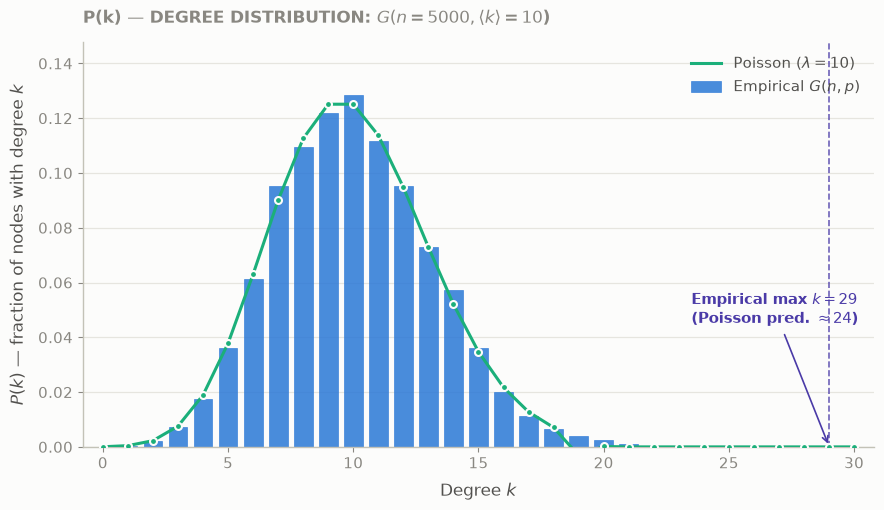

In [3]:
# Figure 1: G(n=5000, <k>=10) vs Poisson
n = 5000
k_mean_1 = 10
p_1 = k_mean_1 / (n - 1)

G_1 = nx.fast_gnp_random_graph(n, p_1, seed=42)
degs_1 = [d for _, d in G_1.degree()]
m_1 = G_1.number_of_edges()
mean_1 = np.mean(degs_1)
max_1 = max(degs_1)
counts_1 = Counter(degs_1)
ks_1 = np.arange(0, max(max_1 + 2, 26))
p_emp_1 = np.array([counts_1[k] / n for k in ks_1])
p_poisson_1 = np.array([math.exp(-k_mean_1) * (k_mean_1**k) / math.factorial(k) for k in ks_1])

pred_k_max = next(k for k in range(k_mean_1, 50) if sum(math.exp(-k_mean_1)*(k_mean_1**j)/math.factorial(j) for j in range(k, 100)) <= 1.0/n)
print(f"G(n=5000, <k>=10): p={p_1:.6f}, edges={m_1:,}, mean_k={mean_1:.2f}, max_k={max_1}, Poisson pred_max_k~{pred_k_max}")

fig, ax = plt.subplots(figsize=(9, 5.2), facecolor=THEME["surface"])
ax.set_facecolor(THEME["surface"])
ax.grid(axis="y", color=THEME["grid"], linestyle="-", linewidth=0.9, alpha=0.8, zorder=0)
ax.set_axisbelow(True)

ax.bar(ks_1, p_emp_1, width=0.75, color=THEME["series_1"], alpha=0.85, edgecolor=THEME["series_1"], linewidth=0.5, label="Empirical $G(n, p)$", zorder=2)
ax.plot(ks_1, p_poisson_1, color=THEME["series_2"], linewidth=2.2, label=f"Poisson ($\lambda = {k_mean_1}$)", zorder=3)
ax.plot(ks_1, p_poisson_1, color=THEME["series_2"], marker="o", markersize=5, markerfacecolor=THEME["series_2"], markeredgecolor=THEME["surface"], markeredgewidth=1.5, linestyle="none", zorder=4)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color(THEME["baseline"])
ax.spines["bottom"].set_color(THEME["baseline"])
ax.tick_params(colors=THEME["text_muted"], labelsize=11)
ax.set_ylim(bottom=0, top=max(p_emp_1.max(), p_poisson_1.max()) * 1.15)
ax.set_xlim(left=-0.8, right=max(ks_1) + 0.8)
ax.set_xlabel("Degree $k$", fontsize=12, color=THEME["text_secondary"], labelpad=8)
ax.set_ylabel("$P(k)$ — fraction of nodes with degree $k$", fontsize=12, color=THEME["text_secondary"], labelpad=8)
ax.set_title("P(k) — DEGREE DISTRIBUTION: $G(n=5000, \\langle k \\rangle=10$)", fontsize=12, fontweight="bold", color=THEME["text_muted"], loc="left", pad=14)

ax.axvline(max_1, color=THEME["accent"], linestyle="--", linewidth=1.2, alpha=0.8, zorder=1)
ax.annotate(f"Empirical max $k = {max_1}$\n(Poisson pred. $\\approx {pred_k_max}$)", xy=(max_1, p_emp_1[max_1]), xytext=(max_1 - 5.5, max(p_emp_1) * 0.35),
            arrowprops=dict(arrowstyle="->", color=THEME["accent"], lw=1.2), fontsize=10.5, color=THEME["accent"], fontweight="bold")
ax.legend(frameon=False, loc="upper right", fontsize=11, labelcolor=THEME["text_secondary"])
plt.tight_layout()
plt.show()

G(n=5000, <k>=100): p=0.020004, edges=249,546, mean_k=99.82, std_k=9.81, max_k=140


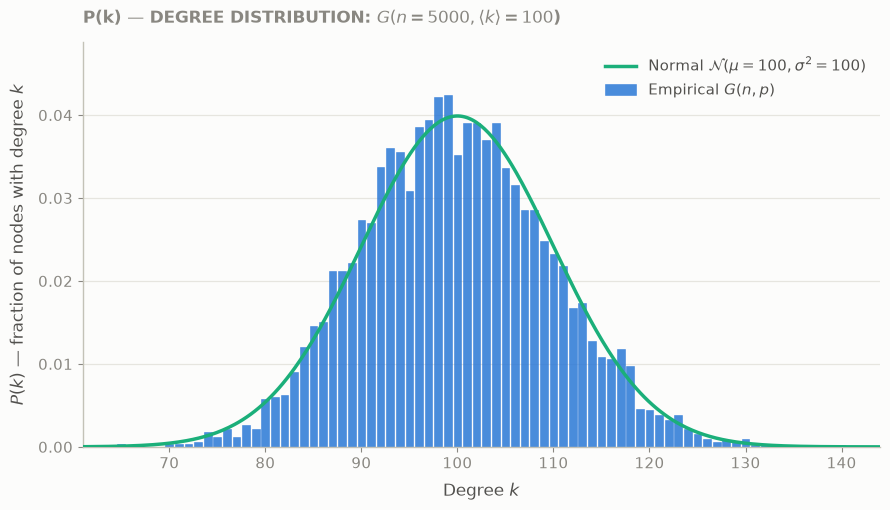

In [7]:
# Figure 2: G(n=5000, <k>=100) vs Normal Distribution
k_mean_2 = 100
p_2 = k_mean_2 / (n - 1)

G_2 = nx.fast_gnp_random_graph(n, p_2, seed=42)
degs_2 = [d for _, d in G_2.degree()]
m_2 = G_2.number_of_edges()
mean_2 = np.mean(degs_2)
std_2 = np.std(degs_2)
max_2 = max(degs_2)
min_2 = min(degs_2)
counts_2 = Counter(degs_2)
ks_2 = np.arange(min_2, max_2 + 1)
p_emp_2 = np.array([counts_2[k] / n for k in ks_2])

mu = k_mean_2
sigma = math.sqrt(k_mean_2)
x_norm = np.linspace(min_2 - 4, max_2 + 4, 400)
pdf_norm = (1.0 / (sigma * math.sqrt(2 * math.pi))) * np.exp(-0.5 * ((x_norm - mu) / sigma)**2)

print(f"G(n=5000, <k>=100): p={p_2:.6f}, edges={m_2:,}, mean_k={mean_2:.2f}, std_k={std_2:.2f}, max_k={max_2}")

fig, ax = plt.subplots(figsize=(9, 5.2), facecolor=THEME["surface"])
ax.set_facecolor(THEME["surface"])
ax.grid(axis="y", color=THEME["grid"], linestyle="-", linewidth=0.9, alpha=0.8, zorder=0)
ax.set_axisbelow(True)

ax.bar(ks_2, p_emp_2, width=0.8, color=THEME["series_1"], alpha=0.85, edgecolor=THEME["series_1"], linewidth=0.4, label="Empirical $G(n, p)$", zorder=2)
ax.plot(x_norm, pdf_norm, color=THEME["series_2"], linewidth=2.5, label=f"Normal $\\mathcal{{N}}(\\mu={mu}, \\sigma^2={mu})$", zorder=3)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color(THEME["baseline"])
ax.spines["bottom"].set_color(THEME["baseline"])
ax.tick_params(colors=THEME["text_muted"], labelsize=11)
ax.set_ylim(bottom=0, top=max(p_emp_2.max(), pdf_norm.max()) * 1.15)
ax.set_xlim(left=min(x_norm), right=max(x_norm))
ax.set_xlabel("Degree $k$", fontsize=12, color=THEME["text_secondary"], labelpad=8)
ax.set_ylabel("$P(k)$ — fraction of nodes with degree $k$", fontsize=12, color=THEME["text_secondary"], labelpad=8)
ax.set_title("P(k) — DEGREE DISTRIBUTION: $G(n=5000, \\langle k \\rangle=100$)", fontsize=12, fontweight="bold", color=THEME["text_muted"], loc="left", pad=14)
ax.legend(frameon=False, loc="upper right", fontsize=11, labelcolor=THEME["text_secondary"])
plt.tight_layout()
plt.show()

In [4]:
# Interactive Explorable: Slider for <k>
slider_k = widgets.SelectionSlider(
    options=[5, 10, 20, 30, 50, 75, 100],
    value=10,
    description="⟨k⟩:",
    continuous_update=False,
)
output_plot = widgets.Output()

def update_plot(change=None):
    k_val = slider_k.value
    p_val = k_val / (n - 1)
    G = nx.fast_gnp_random_graph(n, p_val, seed=42)
    degs = [d for _, d in G.degree()]
    counts = Counter(degs)
    min_k, max_k = min(degs), max(degs)
    ks = np.arange(min_k, max_k + 1)
    p_emp = np.array([counts[k] / n for k in ks])
    
    with output_plot:
        output_plot.clear_output(wait=True)
        fig, ax = plt.subplots(figsize=(9, 5), facecolor=THEME["surface"])
        ax.set_facecolor(THEME["surface"])
        ax.grid(axis="y", color=THEME["grid"], linestyle="-", linewidth=0.9, alpha=0.8, zorder=0)
        ax.set_axisbelow(True)
        
        ax.bar(ks, p_emp, width=0.75, color=THEME["series_1"], alpha=0.85, label="Empirical $G(n, p)$", zorder=2)
        
        if k_val <= 20:
            p_ref = [math.exp(-k_val) * (k_val**k) / math.factorial(k) for k in ks]
            ax.plot(ks, p_ref, color=THEME["series_2"], linewidth=2.2, label=f"Poisson ($\lambda={k_val}$)", zorder=3)
            ax.plot(ks, p_ref, color=THEME["series_2"], marker="o", markersize=5, markerfacecolor=THEME["series_2"], markeredgecolor=THEME["surface"], markeredgewidth=1.5, linestyle="none", zorder=4)
        else:
            mu_val, sig_val = k_val, math.sqrt(k_val)
            x_fit = np.linspace(min_k - 3, max_k + 3, 300)
            pdf_fit = (1.0 / (sig_val * math.sqrt(2 * math.pi))) * np.exp(-0.5 * ((x_fit - mu_val) / sig_val)**2)
            ax.plot(x_fit, pdf_fit, color=THEME["series_2"], linewidth=2.5, label=f"Normal $\\mathcal{{N}}(\\mu={mu_val}, \\sigma^2={mu_val})$", zorder=3)
            
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.spines["left"].set_color(THEME["baseline"])
        ax.spines["bottom"].set_color(THEME["baseline"])
        ax.tick_params(colors=THEME["text_muted"], labelsize=11)
        ax.set_ylim(bottom=0)
        ax.set_xlabel("Degree $k$", fontsize=12, color=THEME["text_secondary"], labelpad=8)
        ax.set_ylabel("$P(k)$", fontsize=12, color=THEME["text_secondary"], labelpad=8)
        ax.set_title(f"P(k) — DEGREE DISTRIBUTION: $G(n=5000, \\langle k \\rangle={k_val})$", fontsize=12, fontweight="bold", color=THEME["text_muted"], loc="left", pad=12)
        ax.legend(frameon=False, loc="upper right", fontsize=11, labelcolor=THEME["text_secondary"])
        plt.tight_layout()
        plt.show()

slider_k.observe(update_plot, names="value")
display(slider_k, output_plot)
update_plot()


<>:31: SyntaxWarning: invalid escape sequence '\l'
<>:31: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_14335/4021667957.py:31: SyntaxWarning: invalid escape sequence '\l'
  ax.plot(ks, p_ref, color=THEME["series_2"], linewidth=2.2, label=f"Poisson ($\lambda={k_val}$)", zorder=3)


SelectionSlider(continuous_update=False, description='⟨k⟩:', index=1, options=(5, 10, 20, 30, 50, 75, 100), va…

Output()

In [8]:
# Exercise 2.1.4: Marvel network versus a matched random network
from IPython.display import HTML
from pathlib import Path


def as_undirected_simple_graph(graph):
    """Use the same undirected simple-graph convention for both networks."""
    return nx.Graph(graph)


# Reuse an earlier Marvel graph when available; otherwise load the supplied Week 1 data.
existing_marvel = globals().get("G_marvel")
existing_graph = globals().get("G")
if existing_marvel is not None:
    marvel_graph = as_undirected_simple_graph(existing_marvel)
elif isinstance(existing_graph, nx.Graph) and existing_graph.number_of_nodes() != n:
    marvel_graph = as_undirected_simple_graph(existing_graph)
else:
    workspace_dir = Path.cwd().parent if Path.cwd().name == "Week2" else Path.cwd()
    nodes_path = workspace_dir / "Week1" / "week1_nodes.tsv"
    edges_path = workspace_dir / "Week1" / "week1_edges.tsv"
    marvel_graph = nx.Graph()
    with nodes_path.open(encoding="utf-8") as nodes_file:
        for line in nodes_file:
            if line.startswith(("#", "node_id")):
                continue
            marvel_graph.add_node(line.rstrip("\n").split("\t", 1)[0])
    with edges_path.open(encoding="utf-8") as edges_file:
        for line in edges_file:
            if line.startswith(("#", "source")):
                continue
            source, target = line.rstrip("\n").split("\t")[:2]
            marvel_graph.add_edge(source, target)

nn = marvel_graph.number_of_nodes()
mm = marvel_graph.number_of_edges()
p_marvel = 2 * mm / (nn * (nn - 1))
random_marvel = nx.gnp_random_graph(nn, p_marvel, seed=42)


def network_summary(graph, label):
    giant_nodes = max(nx.connected_components(graph), key=len)
    giant = graph.subgraph(giant_nodes)
    return {
        "Network": label,
        "Average distance (giant component)": nx.average_shortest_path_length(giant),
        "Giant component size": giant.number_of_nodes(),
        "Number of isolates": nx.number_of_isolates(graph),
        "Maximum degree": max(dict(graph.degree()).values()),
        "Clustering Coefficient": nx.average_clustering(graph),
    }

comparison_table = [
    network_summary(marvel_graph, "Marvel"),
    network_summary(random_marvel, "Random G(n, p)"),
]

print(f"Marvel network: n={nn}, m={mm}, matched p={p_marvel:.6f}")
headers = list(comparison_table[0])
header_html = "".join(f"<th>{header}</th>" for header in headers)
rows_html = "".join(
    "<tr>" + "".join(
        f"<td>{value:.3f}</td>" if isinstance(value, float) else f"<td>{value}</td>"
        for value in row.values()
    ) + "</tr>"
    for row in comparison_table
)
display(HTML(f"<table><thead><tr>{header_html}</tr></thead><tbody>{rows_html}</tbody></table>"))

Marvel network: n=303, m=1434, matched p=0.031342


Network,Average distance (giant component),Giant component size,Number of isolates,Maximum degree,Clustering Coefficient
Marvel,2.674,277,17,106,0.307
"Random G(n, p)",2.773,303,0,18,0.034


In [16]:
# Exercise 2.4 #2: Reproduce the classic figure
# Task: n=500, <k>=4; for each q in {0, 0.01, 0.03, 0.05, 0.1, 0.2} generate 50 networks,
# compute the mean shortest path <d> and the clustering C, and plot both against q (log x-axis)
# with error bars from the standard deviation over the 50 runs. Deliverable matches the explorable's right-hand panel.

import ipywidgets as widgets
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
from IPython.display import display

THEME = globals().get("THEME", {
    "surface": "#fcfcfb", "text_primary": "#0b0b0b", "text_secondary": "#52514e",
    "text_muted": "#898781", "grid": "#e1e0d9", "baseline": "#c3c2b7",
    "series_1": "#2a78d6", "series_2": "#1baf7a", "accent": "#4a3aa7",
})

n = 500
k = 4
qs = [0, 0.01, 0.03, 0.05, 0.1, 0.2]
runs = 50

results = {}
for q in qs:
    ds, cs = [], []
    for r in range(runs):
        G = nx.watts_strogatz_graph(n, k, q, seed=int(round(q * 10000)) + r + 42)
        if nx.is_connected(G):
            d = nx.average_shortest_path_length(G)
        else:
            gcc = G.subgraph(max(nx.connected_components(G), key=len))
            d = nx.average_shortest_path_length(gcc)
        ds.append(d)
        cs.append(nx.average_clustering(G))

    results[q] = {
        "d_mean": float(np.mean(ds)), "d_std": float(np.std(ds)),
        "c_mean": float(np.mean(cs)), "c_std": float(np.std(cs)),
    }

# Normalize against the regular ring lattice at q=0.
d0 = results[0]["d_mean"]
c0 = results[0]["c_mean"]
q_plot_map = {0: 0.0025, 0.01: 0.01, 0.03: 0.03, 0.05: 0.05, 0.1: 0.1, 0.2: 0.2}
q_plot = [q_plot_map[q] for q in qs]
d_means = np.array([results[q]["d_mean"] for q in qs])
d_stds = np.array([results[q]["d_std"] for q in qs])
c_means = np.array([results[q]["c_mean"] for q in qs])
c_stds = np.array([results[q]["c_std"] for q in qs])
L_norm, L_std_norm = d_means / d0, d_stds / d0
C_norm, C_std_norm = c_means / c0, c_stds / c0

slider_q = widgets.SelectionSlider(options=qs, value=0.01, description="rewiring q:", continuous_update=False)
output_view = widgets.Output()


def render_panel(selected_q=0.01):
    with output_view:
        output_view.clear_output(wait=True)
        idx_sel = qs.index(selected_q)
        sel_c_raw = results[selected_q]["c_mean"]
        sel_c_rel, sel_c_rel_std = C_norm[idx_sel], C_std_norm[idx_sel]
        sel_d_raw = results[selected_q]["d_mean"]
        sel_d_rel, sel_d_rel_std = L_norm[idx_sel], L_std_norm[idx_sel]
        exp_shortcuts = int(round(selected_q * (n * k / 2)))

        fig, ax = plt.subplots(figsize=(6.8, 6.1), facecolor=THEME["surface"])
        ax.set_facecolor(THEME["surface"])
        for y_val in [0.0, 0.5, 1.0]:
            ax.axhline(y_val, color=THEME["grid"], linewidth=1.0, zorder=1)

        ax.errorbar(q_plot, C_norm, yerr=C_std_norm, fmt="-o", color=THEME["series_2"],
                    linewidth=2.2, markersize=5, capsize=3, capthick=1.2,
                    label="C(q) / C(0) - clustering", zorder=3)
        ax.errorbar(q_plot, L_norm, yerr=L_std_norm, fmt="-s", color=THEME["series_1"],
                    linewidth=2.2, markersize=5, capsize=3, capthick=1.2,
                    label="L(q) / L(0) - mean distance", zorder=3)
        ax.text(0.015, 0.98, "clustering", color=THEME["text_primary"], fontsize=11, fontweight="bold", ha="center")
        ax.text(0.015, 0.44, "distance", color=THEME["text_primary"], fontsize=11, fontweight="bold", ha="center")

        sel_x = q_plot_map[selected_q]
        ax.axvline(sel_x, color=THEME["baseline"], linestyle="--", linewidth=1.2, alpha=0.85, zorder=2)
        ax.plot(sel_x, C_norm[idx_sel], "o", color=THEME["series_2"], markersize=8,
                markeredgecolor=THEME["surface"], markeredgewidth=1.5, zorder=5)
        ax.plot(sel_x, L_norm[idx_sel], "s", color=THEME["series_1"], markersize=8,
                markeredgecolor=THEME["surface"], markeredgewidth=1.5, zorder=5)

        ax.set_title("CLUSTERING AND DISTANCE VS REWIRING", fontsize=12, fontweight="bold",
                     color=THEME["text_muted"], loc="left", pad=28)
        ax.legend(frameon=False, loc=(-0.02, 1.01), ncol=2, fontsize=10.5,
                  handlelength=1.5, columnspacing=1.5, labelcolor=THEME["text_secondary"])
        ax.set_xscale("log")
        ax.set_xlim(0.0018, 0.25)
        ax.set_ylim(-0.03, 1.05)
        ax.set_yticks([0, 0.5, 1])
        ax.set_yticklabels(["0", "0.5", "1"])
        ax.set_xticks(q_plot)
        ax.set_xticklabels(["0", "0.01", "0.03", "0.05", "0.1", "0.2"])
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.spines["left"].set_color(THEME["baseline"])
        ax.spines["bottom"].set_color(THEME["baseline"])
        ax.tick_params(colors=THEME["text_muted"], labelsize=10.5)
        ax.set_xlabel("rewiring probability q (log)", fontsize=11, color=THEME["text_muted"], labelpad=8)
        ax.set_ylabel("relative to lattice", fontsize=11, color=THEME["text_muted"], labelpad=8)

        readout = (f"C = {sel_c_raw:.3f} (relative: {sel_c_rel:.3f} +/- {sel_c_rel_std:.3f})    "
                   f"mean distance = {sel_d_raw:.2f} (relative: {sel_d_rel:.3f} +/- {sel_d_rel_std:.3f})    "
                   f"expected shortcuts = {exp_shortcuts} / {int(n * k / 2)} edges")
        fig.text(0.04, 0.015, readout, fontsize=9.5, color=THEME["text_secondary"])
        plt.tight_layout(rect=(0, 0.06, 1, 1))
        plt.show()


def on_q_change(change):
    render_panel(change["new"])


slider_q.observe(on_q_change, names="value")
display(widgets.VBox([slider_q, output_view]))
render_panel(slider_q.value)

Preferential attachment: max degree=105
NetworkX BA: max degree=206
Uniform growth: max degree=12, components=1
Matched G(n, m): max degree=8, components=799


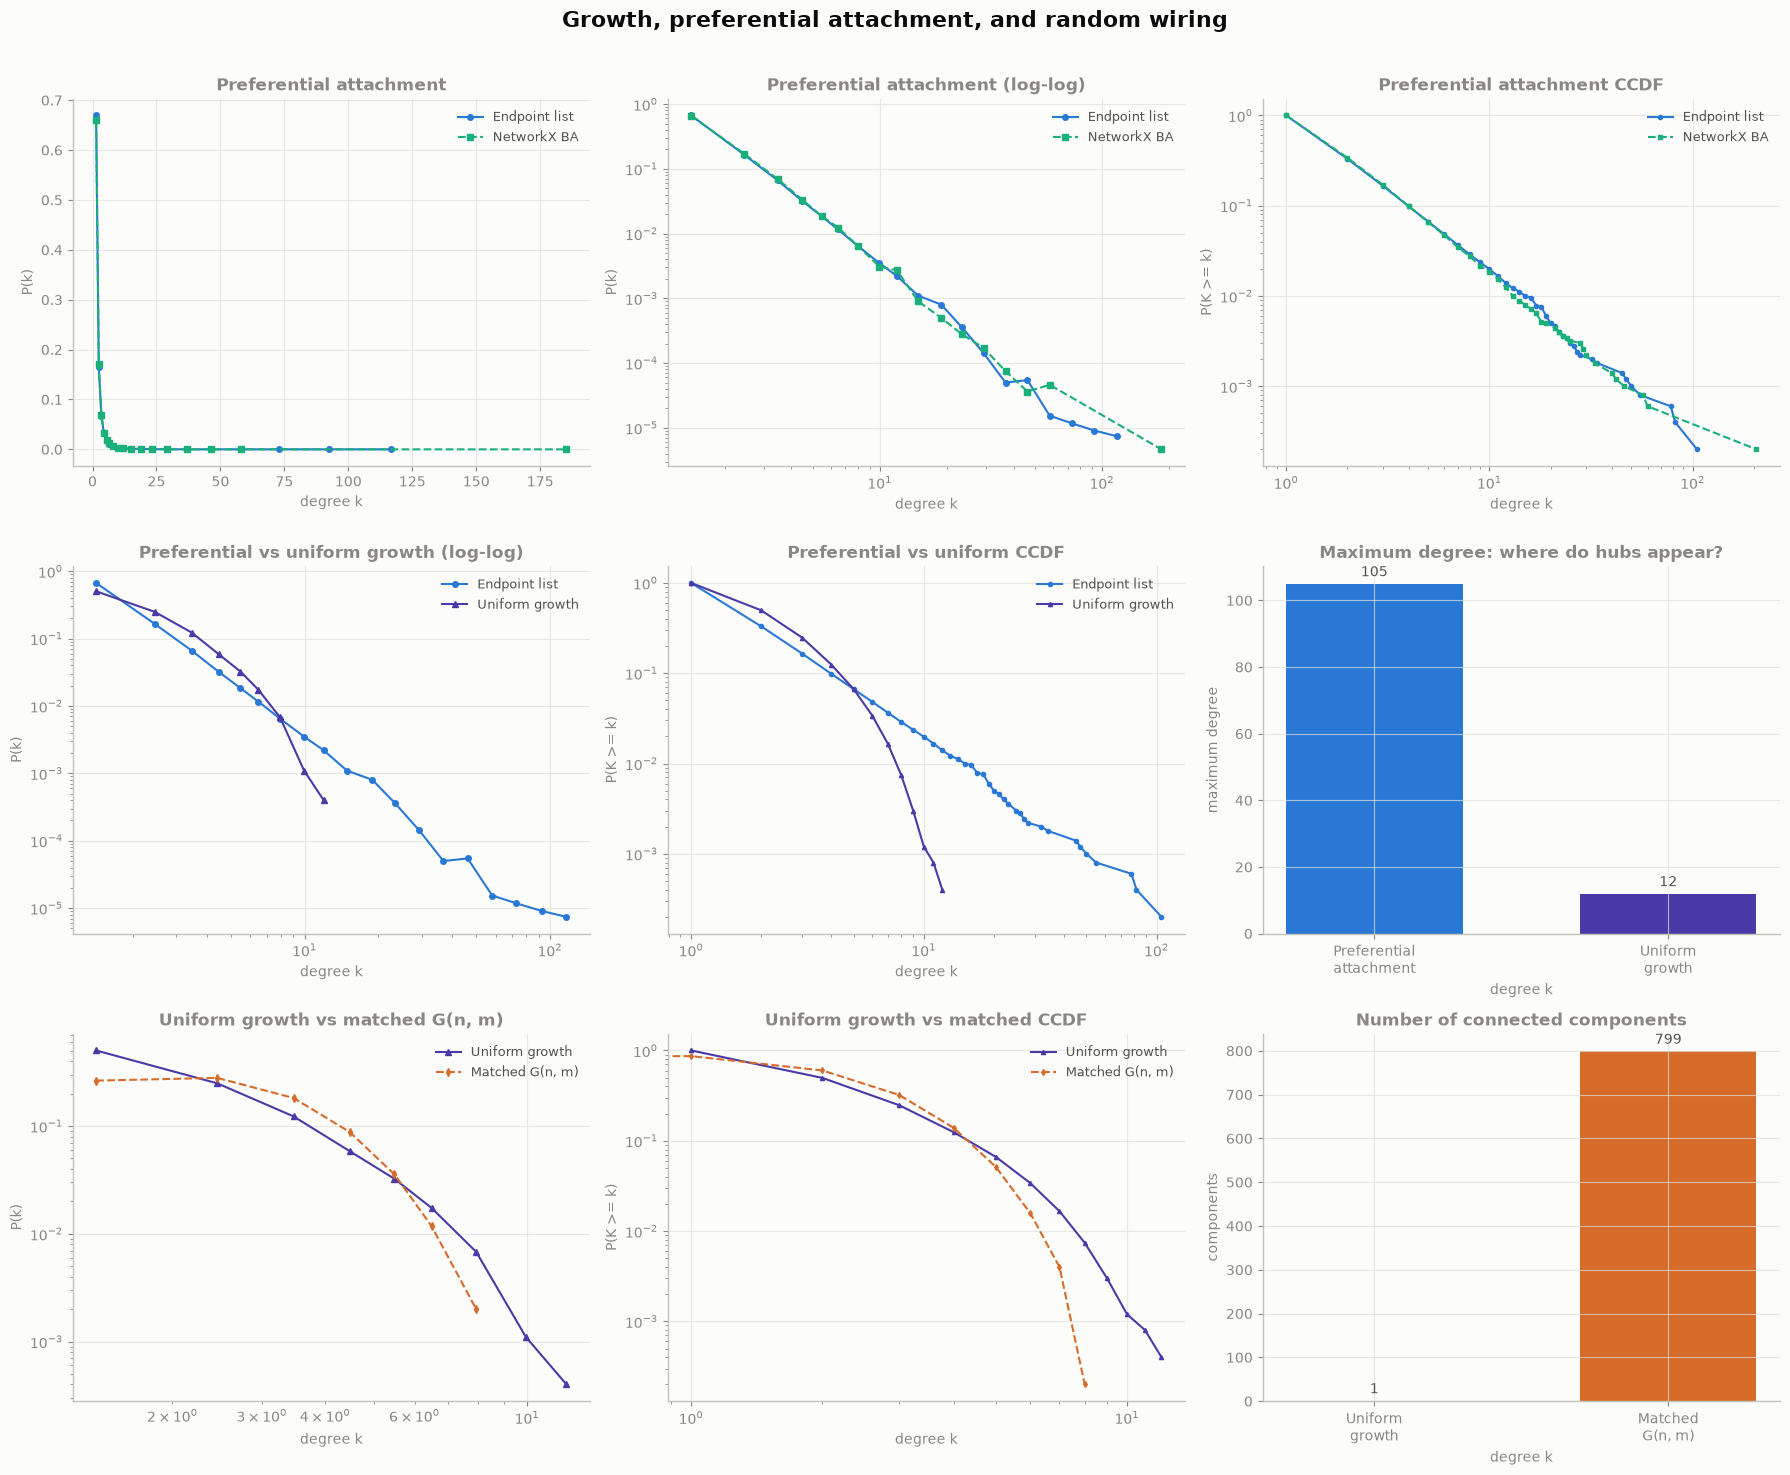

In [26]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np

n = 5_000
rng = np.random.default_rng(42)

# Preferential attachment: sample uniformly from the flat endpoint list.
endpoints = [1, 2]
for new_node in range(3, n + 1):
    selected_endpoint = rng.choice(endpoints)
    endpoints.extend((new_node, int(selected_endpoint)))

preferential_graph = nx.Graph()
preferential_graph.add_edges_from(zip(endpoints[::2], endpoints[1::2]))

# Uniform growth: sample uniformly from the existing node list instead.
uniform_graph = nx.Graph()
uniform_graph.add_edge(1, 2)
for new_node in range(3, n + 1):
    selected_node = int(rng.integers(1, new_node))
    uniform_graph.add_edge(new_node, selected_node)

# Independent checks and the matched random graph.
ba_graph = nx.barabasi_albert_graph(n, 1, seed=42)
random_graph = nx.gnm_random_graph(n, n - 1, seed=42)

def degree_array(graph):
    return np.fromiter((degree for _, degree in graph.degree()), dtype=int)

preferential_degrees = degree_array(preferential_graph)
uniform_degrees = degree_array(uniform_graph)
ba_degrees = degree_array(ba_graph)
random_degrees = degree_array(random_graph)

print(f"Preferential attachment: max degree={preferential_degrees.max()}")
print(f"NetworkX BA: max degree={ba_degrees.max()}")
print(f"Uniform growth: max degree={uniform_degrees.max()}, components={nx.number_connected_components(uniform_graph)}")
print(f"Matched G(n, m): max degree={random_degrees.max()}, components={nx.number_connected_components(random_graph)}")

# Shared logarithmic bins make the overlaid distributions directly comparable.
max_degree = max(map(int, (preferential_degrees.max(), uniform_degrees.max(), ba_degrees.max(), random_degrees.max())))
bin_edges = np.unique(np.ceil(np.logspace(0, np.log10(max_degree + 1), 24)).astype(int))
if bin_edges[0] != 1:
    bin_edges = np.r_[1, bin_edges]
if bin_edges[-1] <= max_degree:
    bin_edges = np.r_[bin_edges, max_degree + 1]
centers = np.sqrt(bin_edges[:-1] * bin_edges[1:])
widths = np.diff(bin_edges)

def binned_density(degree_values):
    counts, _ = np.histogram(degree_values, bins=bin_edges)
    return counts / (len(degree_values) * widths)

def ccdf(degree_values):
    values = np.sort(np.unique(degree_values))
    return values, np.array([(degree_values >= value).mean() for value in values])

distributions = {
    "Endpoint list": binned_density(preferential_degrees),
    "NetworkX BA": binned_density(ba_degrees),
    "Uniform growth": binned_density(uniform_degrees),
    "Matched G(n, m)": binned_density(random_degrees),
}
ccdfs = {
    label: ccdf(values)
    for label, values in {
        "Endpoint list": preferential_degrees,
        "NetworkX BA": ba_degrees,
        "Uniform growth": uniform_degrees,
        "Matched G(n, m)": random_degrees,
    }.items()
}
colors = {
    "Endpoint list": THEME["series_1"],
    "NetworkX BA": THEME["series_2"],
    "Uniform growth": THEME["accent"],
    "Matched G(n, m)": "#d66b2a",
}
styles = {
    "Endpoint list": "o-",
    "NetworkX BA": "s--",
    "Uniform growth": "^-",
    "Matched G(n, m)": "d--",
}

fig, axes = plt.subplots(3, 3, figsize=(18, 15), facecolor=THEME["surface"])
for axis in axes.flat:
    axis.set_facecolor(THEME["surface"])
    axis.spines["top"].set_visible(False)
    axis.spines["right"].set_visible(False)
    axis.spines["left"].set_color(THEME["baseline"])
    axis.spines["bottom"].set_color(THEME["baseline"])
    axis.tick_params(colors=THEME["text_muted"])
    axis.grid(True, color=THEME["grid"], linewidth=0.8, alpha=0.7)
    axis.set_xlabel("degree k", color=THEME["text_muted"])
    axis.set_ylabel("P(k)", color=THEME["text_muted"])

def plot_distribution(axis, labels, log_axes=True):
    for label in labels:
        values = distributions[label]
        mask = values > 0
        axis.plot(centers[mask], values[mask], styles[label], color=colors[label], markersize=4, label=label)
    if log_axes:
        axis.set_xscale("log")
        axis.set_yscale("log")
    axis.legend(frameon=False, fontsize=9, labelcolor=THEME["text_secondary"])

def plot_ccdf(axis, labels):
    for label in labels:
        values, probabilities = ccdfs[label]
        axis.plot(values, probabilities, styles[label], color=colors[label], markersize=3, label=label)
    axis.set_xscale("log")
    axis.set_yscale("log")
    axis.set_ylabel("P(K >= k)", color=THEME["text_muted"])
    axis.legend(frameon=False, fontsize=9, labelcolor=THEME["text_secondary"])

# Row 1: endpoint-list preferential attachment versus NetworkX's BA implementation.
plot_distribution(axes[0, 0], ["Endpoint list", "NetworkX BA"], log_axes=False)
axes[0, 0].set_title("Preferential attachment", fontweight="bold", color=THEME["text_muted"])
plot_distribution(axes[0, 1], ["Endpoint list", "NetworkX BA"])
axes[0, 1].set_title("Preferential attachment (log-log)", fontweight="bold", color=THEME["text_muted"])
plot_ccdf(axes[0, 2], ["Endpoint list", "NetworkX BA"])
axes[0, 2].set_title("Preferential attachment CCDF", fontweight="bold", color=THEME["text_muted"])

# Row 2: preferential attachment versus uniform growth.
plot_distribution(axes[1, 0], ["Endpoint list", "Uniform growth"])
axes[1, 0].set_title("Preferential vs uniform growth (log-log)", fontweight="bold", color=THEME["text_muted"])
plot_ccdf(axes[1, 1], ["Endpoint list", "Uniform growth"])
axes[1, 1].set_title("Preferential vs uniform CCDF", fontweight="bold", color=THEME["text_muted"])
max_labels = ["Preferential\nattachment", "Uniform\ngrowth"]
axes[1, 2].bar(max_labels, [preferential_degrees.max(), uniform_degrees.max()], color=[colors["Endpoint list"], colors["Uniform growth"]], width=0.6)
axes[1, 2].set_title("Maximum degree: where do hubs appear?", fontweight="bold", color=THEME["text_muted"])
axes[1, 2].set_ylabel("maximum degree", color=THEME["text_muted"])

# Row 3: uniform growth versus G(n, m) with the same n and m.
plot_distribution(axes[2, 0], ["Uniform growth", "Matched G(n, m)"])
axes[2, 0].set_title("Uniform growth vs matched G(n, m)", fontweight="bold", color=THEME["text_muted"])
plot_ccdf(axes[2, 1], ["Uniform growth", "Matched G(n, m)"])
axes[2, 1].set_title("Uniform growth vs matched CCDF", fontweight="bold", color=THEME["text_muted"])
component_labels = ["Uniform\ngrowth", "Matched\nG(n, m)"]
component_counts = [nx.number_connected_components(uniform_graph), nx.number_connected_components(random_graph)]
axes[2, 2].bar(component_labels, component_counts, color=[colors["Uniform growth"], colors["Matched G(n, m)"]], width=0.6)
axes[2, 2].set_title("Number of connected components", fontweight="bold", color=THEME["text_muted"])
axes[2, 2].set_ylabel("components", color=THEME["text_muted"])

for axis in [axes[1, 2], axes[2, 2]]:
    for container in axis.containers:
        axis.bar_label(container, color=THEME["text_secondary"], padding=3)

fig.suptitle("Growth, preferential attachment, and random wiring", fontsize=16, fontweight="bold", color=THEME["text_primary"])
plt.tight_layout(rect=(0, 0, 1, 0.97))
plt.show()

Marvel giant component: n=277, m=1,421, real CC=0.3199
Configuration model link cost: 10,266 total (102.66 +/- 7.84 per network)
Configuration model: mean CC=0.1120, SD=0.0086, z=24.16, empirical p=0.000, normal-approximation p=2.944e-129
G(n,m): mean CC=0.0370, SD=0.0029, z=97.71, empirical p=0.000, normal-approximation p=0.000e+00


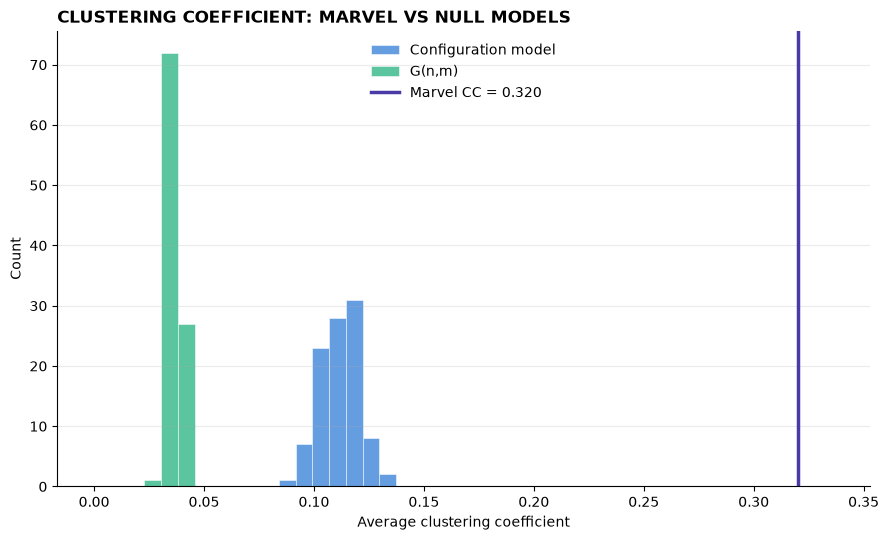

In [3]:
import csv
import math
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np

base_dir = Path("/home/borkeren/Desktop/SocialGraphs/Week1")
node_file = base_dir / "week1_nodes.tsv"
edge_file = base_dir / "week1_edges.tsv"


def read_tsv_rows(path, header_prefix):
    lines = path.read_text(encoding="utf-8").splitlines()
    header_index = next(i for i, line in enumerate(lines) if line.lstrip("# ").startswith(header_prefix))
    cleaned_lines = [lines[header_index].lstrip("# ").strip()]
    cleaned_lines.extend(line for line in lines[header_index + 1:] if line.strip() and not line.startswith("#"))
    return list(csv.DictReader(cleaned_lines, delimiter="\t"))


node_rows = read_tsv_rows(node_file, "node_id\t")
edge_rows = read_tsv_rows(edge_file, "source\t")

node_ids = [row["node_id"] for row in node_rows]
edges = [(row["source"], row["target"]) for row in edge_rows]

G_undirected = nx.Graph()
G_undirected.add_nodes_from(node_ids)
G_undirected.add_edges_from(edges)


# Work with the undirected giant component of the Marvel network.
marvel_giant_nodes = max(nx.connected_components(G_undirected), key=len)
marvel = G_undirected.subgraph(marvel_giant_nodes).copy()

n_marvel = marvel.number_of_nodes()
m_marvel = marvel.number_of_edges()
real_clustering = nx.average_clustering(marvel)
degree_sequence = [degree for _, degree in marvel.degree()]
assert sum(degree_sequence) % 2 == 0

n_null = 100
configuration_clusterings = []
configuration_link_costs = []
gnm_clusterings = []

for seed in range(n_null):
    configuration_multigraph = nx.configuration_model(degree_sequence, seed=seed)
    configuration_graph = nx.Graph(configuration_multigraph)
    configuration_graph.remove_edges_from(nx.selfloop_edges(configuration_graph))
    configuration_link_costs.append(m_marvel - configuration_graph.number_of_edges())
    configuration_clusterings.append(nx.average_clustering(configuration_graph))

    gnm_graph = nx.gnm_random_graph(n_marvel, m_marvel, seed=seed)
    gnm_clusterings.append(nx.average_clustering(gnm_graph))

configuration_clusterings = np.asarray(configuration_clusterings)
gnm_clusterings = np.asarray(gnm_clusterings)
configuration_link_costs = np.asarray(configuration_link_costs)

configuration_z = (real_clustering - configuration_clusterings.mean()) / configuration_clusterings.std(ddof=1)
configuration_p = np.mean(configuration_clusterings >= real_clustering)
configuration_normal_p = 0.5 * math.erfc(configuration_z / math.sqrt(2))
gnm_z = (real_clustering - gnm_clusterings.mean()) / gnm_clusterings.std(ddof=1)
gnm_p = np.mean(gnm_clusterings >= real_clustering)
gnm_normal_p = 0.5 * math.erfc(gnm_z / math.sqrt(2))

print(f"Marvel giant component: n={n_marvel:,}, m={m_marvel:,}, real CC={real_clustering:.4f}")
print(
    "Configuration model link cost: "
    f"{configuration_link_costs.sum():,} total "
    f"({configuration_link_costs.mean():.2f} +/- {configuration_link_costs.std(ddof=1):.2f} per network)"
)
print(
    "Configuration model: "
    f"mean CC={configuration_clusterings.mean():.4f}, "
    f"SD={configuration_clusterings.std(ddof=1):.4f}, "
    f"z={configuration_z:.2f}, empirical p={configuration_p:.3f}, "
    f"normal-approximation p={configuration_normal_p:.3e}"
)
print(
    "G(n,m): "
    f"mean CC={gnm_clusterings.mean():.4f}, "
    f"SD={gnm_clusterings.std(ddof=1):.4f}, "
    f"z={gnm_z:.2f}, empirical p={gnm_p:.3f}, "
    f"normal-approximation p={gnm_normal_p:.3e}"
)

fig, ax = plt.subplots(figsize=(9, 5.5))
all_clusterings = np.concatenate([configuration_clusterings, gnm_clusterings, [real_clustering]])
bins = np.linspace(0, max(all_clusterings) * 1.05, 45)
ax.hist(configuration_clusterings, bins=bins, alpha=0.72, color="#2a78d6", edgecolor="white", linewidth=0.5, label="Configuration model")
ax.hist(gnm_clusterings, bins=bins, alpha=0.72, color="#1baf7a", edgecolor="white", linewidth=0.5, label="G(n,m)")
ax.axvline(real_clustering, color="#4a3aa7", linewidth=2.5, label=f"Marvel CC = {real_clustering:.3f}")
ax.set_title("CLUSTERING COEFFICIENT: MARVEL VS NULL MODELS", loc="left", fontsize=12, fontweight="bold")
ax.set_xlabel("Average clustering coefficient")
ax.set_ylabel("Count")
ax.grid(axis="y", alpha=0.25)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()


Edge-swap null model: 14,210 swaps per network (10 x m)
Degree sequence unchanged in every network: True
Edge swaps: mean CC=0.1552, SD=0.0084, z=19.54, empirical p=0.000, normal-approximation p=2.324e-85
Explorable comparison: real CC=0.3199; configuration mean CC=0.1120; edge-swap mean CC=0.1552


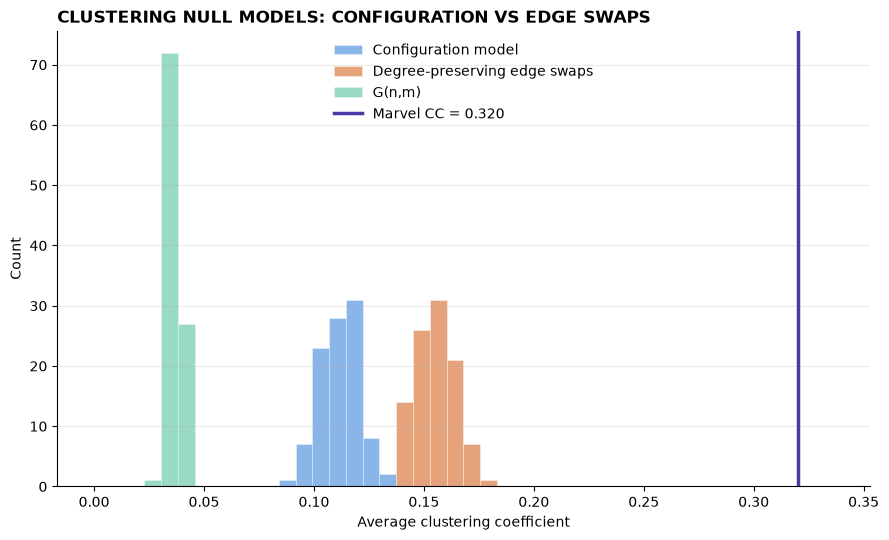

In [4]:
import math

# Degree-preserving edge-swap null model, starting from the real Marvel giant component.
edge_swap_factor = 10
edge_swap_count = edge_swap_factor * m_marvel
real_degree_sequence = sorted(dict(marvel.degree()).values())
edge_swap_clusterings = []
edge_swap_degree_checks = []

for seed in range(n_null):
    swapped_graph = marvel.copy()
    nx.double_edge_swap(
        swapped_graph,
        nswap=edge_swap_count,
        max_tries=100 * edge_swap_count,
        seed=seed,
    )
    swapped_degree_sequence = sorted(dict(swapped_graph.degree()).values())
    degree_sequence_unchanged = swapped_degree_sequence == real_degree_sequence
    edge_swap_degree_checks.append(degree_sequence_unchanged)
    assert degree_sequence_unchanged
    edge_swap_clusterings.append(nx.average_clustering(swapped_graph))

edge_swap_clusterings = np.asarray(edge_swap_clusterings)
edge_swap_degree_checks = np.asarray(edge_swap_degree_checks)
edge_swap_z = (real_clustering - edge_swap_clusterings.mean()) / edge_swap_clusterings.std(ddof=1)
edge_swap_p = np.mean(edge_swap_clusterings >= real_clustering)
edge_swap_normal_p = 0.5 * math.erfc(edge_swap_z / math.sqrt(2))

print(f"Edge-swap null model: {edge_swap_count:,} swaps per network ({edge_swap_factor} x m)")
print(f"Degree sequence unchanged in every network: {edge_swap_degree_checks.all()}")
print(
    "Edge swaps: "
    f"mean CC={edge_swap_clusterings.mean():.4f}, "
    f"SD={edge_swap_clusterings.std(ddof=1):.4f}, "
    f"z={edge_swap_z:.2f}, empirical p={edge_swap_p:.3f}, "
    f"normal-approximation p={edge_swap_normal_p:.3e}"
)
print(
    "Explorable comparison: "
    f"real CC={real_clustering:.4f}; configuration mean CC={configuration_clusterings.mean():.4f}; "
    f"edge-swap mean CC={edge_swap_clusterings.mean():.4f}"
)

fig, ax = plt.subplots(figsize=(9, 5.5))
comparison_values = np.concatenate([
    configuration_clusterings,
    edge_swap_clusterings,
    gnm_clusterings,
    [real_clustering],
])
comparison_bins = np.linspace(0, comparison_values.max() * 1.05, 45)
ax.hist(configuration_clusterings, bins=comparison_bins, alpha=0.55, color="#2a78d6", edgecolor="white", linewidth=0.45, label="Configuration model")
ax.hist(edge_swap_clusterings, bins=comparison_bins, alpha=0.62, color="#d66b2a", edgecolor="white", linewidth=0.45, label="Degree-preserving edge swaps")
ax.hist(gnm_clusterings, bins=comparison_bins, alpha=0.45, color="#1baf7a", edgecolor="white", linewidth=0.45, label="G(n,m)")
ax.axvline(real_clustering, color="#4a3aa7", linewidth=2.5, label=f"Marvel CC = {real_clustering:.3f}")
ax.set_title("CLUSTERING NULL MODELS: CONFIGURATION VS EDGE SWAPS", loc="left", fontsize=12, fontweight="bold")
ax.set_xlabel("Average clustering coefficient")
ax.set_ylabel("Count")
ax.grid(axis="y", alpha=0.25)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()


In [6]:
# Why the two null models differ: inspect the links lost when simplifying configuration models.
configuration_degree_losses = []
configuration_edge_counts = []

for seed in range(n_null):
    configuration_multigraph = nx.configuration_model(degree_sequence, seed=seed)
    simplified_graph = nx.Graph(configuration_multigraph)
    simplified_graph.remove_edges_from(nx.selfloop_edges(simplified_graph))
    configuration_degree_losses.append([
        degree_sequence[node] - simplified_graph.degree(node)
        for node in range(n_marvel)
    ])
    configuration_edge_counts.append(simplified_graph.number_of_edges())

configuration_degree_losses = np.asarray(configuration_degree_losses)
configuration_edge_counts = np.asarray(configuration_edge_counts)
mean_degree_loss = configuration_degree_losses.mean(axis=0)
original_degrees = np.asarray(degree_sequence)
mean_lost_degree_ends = mean_degree_loss.sum()

print(
    f"Configuration simplification: mean m={configuration_edge_counts.mean():.2f} "
    f"instead of {m_marvel:,}; mean loss={m_marvel - configuration_edge_counts.mean():.2f} links"
)
print(
    f"That is {mean_lost_degree_ends:.2f} lost degree-ends per network, "
    f"or {100 * mean_lost_degree_ends / sum(degree_sequence):.1f}% of all degree-ends."
)
print(
    f"Mean degree loss per node: {mean_degree_loss.mean():.3f}; "
    f"largest hub degree={original_degrees.max()}, "
    f"hub loss={mean_degree_loss[original_degrees.argmax()]:.2f}"
)
print(
    f"Correlation between original degree and expected lost degree: "
    f"{np.corrcoef(original_degrees, mean_degree_loss)[0, 1]:.3f}"
)

loss_bins = [0, 2, 5, 10, np.inf]
loss_labels = ["degree 0-2", "degree 3-5", "degree 6-10", "degree 11+"]
print("\nLost degree-ends by original degree:")
for lower, upper, label in zip(loss_bins[:-1], loss_bins[1:], loss_labels):
    group = (original_degrees > lower) & (original_degrees <= upper)
    print(
        f"{label}: nodes={group.sum():3d}, "
        f"mean degree={original_degrees[group].mean():5.2f}, "
        f"mean lost={mean_degree_loss[group].mean():5.2f}, "
        f"relative loss={100 * (mean_degree_loss[group] / original_degrees[group]).mean():5.1f}%"
    )

print(
    "\nInterpretation: edge swaps keep all original degree ends and all m links. "
    "Configuration simplification deletes collisions, especially around high-degree nodes, "
    "so it no longer has the exact original degree sequence."
)


Configuration simplification: mean m=1318.34 instead of 1,421; mean loss=102.66 links
That is 205.32 lost degree-ends per network, or 7.2% of all degree-ends.
Mean degree loss per node: 0.741; largest hub degree=106, hub loss=28.96
Correlation between original degree and expected lost degree: 0.903

Lost degree-ends by original degree:
degree 0-2: nodes= 40, mean degree= 1.55, mean lost= 0.00, relative loss=  0.2%
degree 3-5: nodes= 73, mean degree= 3.92, mean lost= 0.05, relative loss=  1.1%
degree 6-10: nodes= 73, mean degree= 7.56, mean lost= 0.21, relative loss=  2.7%
degree 11+: nodes= 91, mean degree=21.34, mean lost= 2.05, relative loss=  7.3%

Interpretation: edge swaps keep all original degree ends and all m links. Configuration simplification deletes collisions, especially around high-degree nodes, so it no longer has the exact original degree sequence.


In [7]:
# Compare transitivity and isolated nodes across the same null models.
real_transitivity = nx.transitivity(marvel)
real_isolates = nx.number_of_isolates(marvel)

configuration_transitivities = []
configuration_isolates = []
edge_swap_transitivities = []
edge_swap_isolates = []
gnm_transitivities = []
gnm_isolates = []

for seed in range(n_null):
    configuration_multigraph = nx.configuration_model(degree_sequence, seed=seed)
    configuration_graph = nx.Graph(configuration_multigraph)
    configuration_graph.remove_edges_from(nx.selfloop_edges(configuration_graph))
    configuration_transitivities.append(nx.transitivity(configuration_graph))
    configuration_isolates.append(nx.number_of_isolates(configuration_graph))

    swapped_graph = marvel.copy()
    nx.double_edge_swap(
        swapped_graph,
        nswap=edge_swap_count,
        max_tries=100 * edge_swap_count,
        seed=seed,
    )
    edge_swap_transitivities.append(nx.transitivity(swapped_graph))
    edge_swap_isolates.append(nx.number_of_isolates(swapped_graph))

    gnm_graph = nx.gnm_random_graph(n_marvel, m_marvel, seed=seed)
    gnm_transitivities.append(nx.transitivity(gnm_graph))
    gnm_isolates.append(nx.number_of_isolates(gnm_graph))

configuration_transitivities = np.asarray(configuration_transitivities)
configuration_isolates = np.asarray(configuration_isolates)
edge_swap_transitivities = np.asarray(edge_swap_transitivities)
edge_swap_isolates = np.asarray(edge_swap_isolates)
gnm_transitivities = np.asarray(gnm_transitivities)
gnm_isolates = np.asarray(gnm_isolates)


def summarize_null(real_value, null_values, label):
    mean_value = null_values.mean()
    standard_deviation = null_values.std(ddof=1)
    if standard_deviation == 0:
        z_score = np.nan
        normal_p = np.nan
    else:
        z_score = (real_value - mean_value) / standard_deviation
        normal_p = math.erfc(abs(z_score) / math.sqrt(2))
    empirical_p = np.mean(np.abs(null_values - mean_value) >= abs(real_value - mean_value))
    print(
        f"{label}: mean={mean_value:.4f}, SD={standard_deviation:.4f}, "
        f"real={real_value:.4f}, z={z_score:.2f}, two-sided empirical p={empirical_p:.3f}, "
        f"two-sided normal p={normal_p:.3e}"
    )


print("\nTRANSITIVITY")
print(f"Marvel real transitivity: {real_transitivity:.4f}")
summarize_null(real_transitivity, configuration_transitivities, "Configuration model")
summarize_null(real_transitivity, edge_swap_transitivities, "Degree-preserving edge swaps")
summarize_null(real_transitivity, gnm_transitivities, "G(n,m)")

print("\nISOLATED NODES")
print(f"Marvel real isolated nodes: {real_isolates}")
summarize_null(real_isolates, configuration_isolates.astype(float), "Configuration model")
summarize_null(real_isolates, edge_swap_isolates.astype(float), "Degree-preserving edge swaps")
summarize_null(real_isolates, gnm_isolates.astype(float), "G(n,m)")



TRANSITIVITY
Marvel real transitivity: 0.1823
Configuration model: mean=0.1031, SD=0.0047, real=0.1823, z=16.97, two-sided empirical p=0.000, two-sided normal p=1.422e-64
Degree-preserving edge swaps: mean=0.1180, SD=0.0043, real=0.1823, z=14.99, two-sided empirical p=0.000, two-sided normal p=8.366e-51
G(n,m): mean=0.0369, SD=0.0027, real=0.1823, z=54.72, two-sided empirical p=0.000, two-sided normal p=0.000e+00

ISOLATED NODES
Marvel real isolated nodes: 0
Configuration model: mean=0.0200, SD=0.1407, real=0.0000, z=-0.14, two-sided empirical p=1.000, two-sided normal p=8.870e-01
Degree-preserving edge swaps: mean=0.0000, SD=0.0000, real=0.0000, z=nan, two-sided empirical p=1.000, two-sided normal p=nan
G(n,m): mean=0.0100, SD=0.1000, real=0.0000, z=-0.10, two-sided empirical p=1.000, two-sided normal p=9.203e-01
